In [56]:
import pandas as pd
import numpy.random as npr
import numpy as np
import random
import string
from fastparquet import ParquetFile

pd.set_option("mode.copy_on_write", True)
prescription = pd.read_parquet(
    "https://github.com/nickeubank/ids540_opioid_data/raw/refs/heads/main/ids590_opioids_by_drug_county_year.parquet"
)

prescription.head(n=5)
# prescription.drug_name.value_counts()

,buyer_state,buyer_county,year,drug_name,mme_conversion_factor,calc_base_wt_in_gm
0,AK,ANCHORAGE,2006,BUPRENORPHINE,30.00,125.154336
1,AK,ANCHORAGE,2006,BUPRENORPHINE,75.00,0.216367
2,AK,ANCHORAGE,2006,CODEINE,0.15,13362.990030
3,AK,ANCHORAGE,2006,DIHYDROCODEINE,0.25,4.272640
4,AK,ANCHORAGE,2006,FENTANYL,100.00,476.051283


# Notes on initial observations: 

>## Initial research
> * In this data, the data is divided by state, county, year, and drug. 
> * " The MME conversion factor is intended only for analytic purposes where prescription data are used to calculate daily MME.
Use the formula: Strength per Unit X (Number of Units/ Days Supply) X MME conversion factor = MME/Day. " 
> * MME is per milligram, while weight is in grams 

>## Condensing Rows 
>* To condense to adjust for determining drug prescriptions ( multiply MME conversion factor with weight to get a standardized effect of all the opioids bought )
> ** MME conversion factor is in mg while wt is in gm (milligrams vs grams) --> standarize to grams 
>* Condense by adding all the standardized scores (to morphine) together so that there is one row per state,county,year (At end there should be 4 columns)

>## Step 3: Removing states




In [57]:
# prescription.calc_base_wt_in_gm.value_counts(normalize=True)
prescription.calc_base_wt_in_gm.describe()
prescription.calc_base_wt_in_gm.value_counts()
# prescription.calc_base_wt_in_gm.describe()

calc_base_wt_in_gm
0.720000      2912
0.360000      2246
1.440000      1734
1.068160      1322
2.136320      1215
              ... 
1.290900         1
300.204239       1
12.722710        1
332.579520       1
33.141598        1
Name: count, Length: 349912, dtype: int64

In [58]:
prescription.sample(n=10)
total_rows = len(prescription)
print(total_rows)

563631


> Checking that all the conversion factors are greater than 0 since they are a fraction ratio compared to morphine 

In [59]:
assert (prescription.mme_conversion_factor > 0).all()
assert (prescription.mme_conversion_factor > 0).any()
assert (prescription.mme_conversion_factor != np.nan).all()

> All ther conversion factors seem to be correct

### Checking that all the weight in grams are greater than 0, since looking at the table, if there are 0 values of a drug, the drug name is not included 

In [60]:
assert (prescription.calc_base_wt_in_gm > 0).all()
assert (prescription.calc_base_wt_in_gm > 0).any()
assert (prescription.calc_base_wt_in_gm != np.nan).all()

# assert not prescription.duplicated(["buyer_state", "buyer_county", "year"]).any()

In [61]:
print(prescription["mme_conversion_factor"].dtype)

print(prescription["calc_base_wt_in_gm"].dtype)

float64
float64


### Data Checks for mme conversion factor and calc_base_wt_in_gm = Complete 

# Step 2: Filter to Florida + 4 control States (North Carolina, Wisconsin, Colorado, and Nevada)


In [62]:
desired_states = ["FL", "NC", "WI", "CO", "NV"]
masc = prescription["buyer_state"].isin(desired_states)
condensed_prescription = prescription[masc]


condensed_prescription.head()


print(condensed_prescription.buyer_state.value_counts())

condensed_prescription.sample(n=20)

results = {}

results["condensed_length"] = len(condensed_prescription)

print(results["condensed_length"])

condensed_prescription.sample(n=20)

buyer_state
NC    19859
FL    14054
WI    13205
CO     9797
NV     2642
AZ        0
AK        0
AS        0
AL        0
DC        0
DE        0
GA        0
GU        0
HI        0
IA        0
ID        0
IL        0
IN        0
KS        0
KY        0
LA        0
MA        0
CA        0
CT        0
AR        0
MI        0
ME        0
MD        0
MP        0
MS        0
MT        0
ND        0
MN        0
NE        0
NH        0
NJ        0
NM        0
NY        0
OH        0
OK        0
MO        0
OR        0
PA        0
PW        0
PR        0
SC        0
SD        0
TN        0
RI        0
TX        0
UT        0
VI        0
VA        0
VT        0
WA        0
WV        0
WY        0
Name: count, dtype: int64
59557


,buyer_state,buyer_county,year,drug_name,mme_conversion_factor,calc_base_wt_in_gm
541798,WI,KENOSHA,2019,BUPRENORPHINE,75.00,16.700000
70836,FL,UNION,2008,CODEINE,0.15,1175.028200
543794,WI,MONROE,2015,FENTANYL,100.00,92.655925
50364,CO,LA PLATA,2014,TAPENTADOL,0.40,433.500000
544823,WI,PIERCE,2007,"OPIUM, POWDERED",1.00,1.800000
60964,FL,ESCAMBIA,2007,METHADONE,3.00,57.719218
545628,WI,RACINE,2010,METHADONE,3.00,17.440800
58042,FL,BAKER,2011,OXYMORPHONE,3.00,468.129475
543006,WI,MARATHON,2014,MEPERIDINE,0.10,107.020200
537529,WI,BURNETT,2009,HYDROCODONE,1.00,1016.366211


> Notes: Previous section was focused on reducing rows to only include Florida and the control states (Colorado, Nevada, Wisconsin, North Carolina). Using value counts, I checked that the row numbers decreased and when looking at a sample, the only values for the states were the ones previously mentioned. 

In [63]:
condensed_prescription.year.value_counts()

desired_years = [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
masc2 = condensed_prescription["year"].isin(desired_years)
prescription_short = condensed_prescription[masc2]

prescription_short.sample(n=20)

prescription_short.year.value_counts()
prescription_short.head(n=5)

,buyer_state,buyer_county,year,drug_name,mme_conversion_factor,calc_base_wt_in_gm
45167,CO,ADAMS,2006,BUPRENORPHINE,30.00,164.462142
45168,CO,ADAMS,2006,BUPRENORPHINE,75.00,0.414704
45169,CO,ADAMS,2006,CODEINE,0.15,13823.100436
45170,CO,ADAMS,2006,DIHYDROCODEINE,0.25,25.515358
45171,CO,ADAMS,2006,FENTANYL,100.00,436.142346


> Code above shortened the years to include only the values we plan to use in our study (2006-2014)

In [64]:
# Check for missing Values

prescription_short.loc[pd.isnull(prescription_short.mme_conversion_factor)]

prescription_short.loc[pd.isnull(prescription_short.calc_base_wt_in_gm)]

,buyer_state,buyer_county,year,drug_name,mme_conversion_factor,calc_base_wt_in_gm


In [65]:
prescription_short["mge_conversion_factor"] = (
    prescription_short["mme_conversion_factor"] / 1000
)


prescription_short["opioid_strength"] = (
    prescription_short["mge_conversion_factor"]
    * prescription_short["calc_base_wt_in_gm"]
)
prescription_short.head()


assert (prescription_short.opioid_strength > 0).all()
assert (prescription_short.opioid_strength > 0).any()

subset_prescription = prescription_short[
    ["buyer_state", "buyer_county", "year", "opioid_strength"]
]

subset_prescription.head()

,buyer_state,buyer_county,year,opioid_strength
45167,CO,ADAMS,2006,4.933864
45168,CO,ADAMS,2006,0.031103
45169,CO,ADAMS,2006,2.073465
45170,CO,ADAMS,2006,0.006379
45171,CO,ADAMS,2006,43.614235


> Code above first changed the mme conversion factor from milligrams to grams by dividing the entire column by 1000. 
> Next, created a new column multiplying the new mme conversion factor in grams by the amount of prescription in weight per grams, naming that column opiod_strength
> Finally, subset the data so that only the buyer state, buyer county, year, and new opiod_strength columsn were visible. 
> Next, I will use the groupby function to condense so there is only one opioid strength value per state,county,year grouping. 

# Notes: 
Number of counties per state should be: 
72 wisconisn 
67 florida 
100 nc 
64 CO
17 Nevada 


years = 9

There should be 2880 rows in the dataset 
9(320) = 2880

There is currently only 2500. This is because some of the counties are missing and additionally, there is an issue because the states won't merge. 

Next steps would be to use fips with county level population and add the missing counties with 0 values. Then we would need to see if we can adjust the groupby function to be by state, county, and year. Finally, we would recheck it by checking them amount of rows in the dataset. 

In [ ]:
b = open("2000.csv", "rb").read()
text = b.decode("cp1252")  # or use detected encoding
open("2000_utf8.csv", "w", encoding="utf-8").write(text)
# now read the UTF-8 file
population_2000 = pd.read_csv("2000_utf8.csv")
population_2000.head()

,SUMLEV,REGION,DIVISION,STATE,COUNTY,STNAME,CTYNAME,ESTIMATESBASE2000,POPESTIMATE2000,POPESTIMATE2001,POPESTIMATE2002,POPESTIMATE2003,POPESTIMATE2004,POPESTIMATE2005,POPESTIMATE2006,POPESTIMATE2007,POPESTIMATE2008,POPESTIMATE2009,CENSUS2010POP,POPESTIMATE2010
0,40,3,6,1,0,Alabama,Alabama,4447207,4452173,4467634,4480089,4503491,4530729,4569805,4628981,4672840,4718206,4757938,4779736,4785298
1,50,3,6,1,1,Alabama,Autauga County,43751,44021,44889,45909,46800,48366,49676,51328,52405,53277,54135,54571,54632
2,50,3,6,1,3,Alabama,Baldwin County,140416,141342,144875,147957,151509,156266,162183,168121,172404,175827,179406,182265,183195
3,50,3,6,1,5,Alabama,Barbour County,29042,29015,28863,28653,28594,28287,28027,27861,27757,27808,27657,27457,27411
4,50,3,6,1,7,Alabama,Bibb County,19856,19913,21028,21199,21399,21721,22042,22099,22438,22705,22941,22915,22867


In [ ]:
c = open("2010.csv", "rb").read()
text = c.decode("cp1252")  # or use detected encoding
open("2010_utf8.csv", "w", encoding="utf-8").write(text)
# now read the UTF-8 file
population_2010 = pd.read_csv("2010_utf8.csv")
population_2010.head()

,SUMLEV,REGION,DIVISION,STATE,COUNTY,STNAME,CTYNAME,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,...,RDOMESTICMIG2019,RNETMIG2011,RNETMIG2012,RNETMIG2013,RNETMIG2014,RNETMIG2015,RNETMIG2016,RNETMIG2017,RNETMIG2018,RNETMIG2019
0,40,3,6,1,0,Alabama,Alabama,4779736,4780125,4785437,...,1.917501,0.578434,1.186314,1.522549,0.563489,0.626357,0.745172,1.090366,1.773786,2.483744
1,50,3,6,1,1,Alabama,Autauga County,54571,54597,54773,...,4.847310,6.018182,-6.226119,-3.902226,1.970443,-1.712875,4.777171,0.849656,0.540916,4.560062
2,50,3,6,1,3,Alabama,Baldwin County,182265,182265,183112,...,24.017829,16.641870,17.488579,22.751474,20.184334,17.725964,21.279291,22.398256,24.727215,24.380567
3,50,3,6,1,5,Alabama,Barbour County,27457,27455,27327,...,-5.690302,0.292676,-6.897817,-8.132185,-5.140431,-15.724575,-18.238016,-24.998528,-8.754922,-5.165664
4,50,3,6,1,7,Alabama,Bibb County,22915,22915,22870,...,1.385134,-4.998356,-3.787545,-5.797999,1.331144,1.329817,-0.708717,-3.234669,-6.857092,1.831952


In [ ]:
required_FIPS_pop_2010 = ["STATE", "COUNTY", "STNAME", "CTYNAME"]
fips_info = population_2010[required_FIPS_pop_2010]
fips_info.sample(n=10)

desired_stname = ["Florida", "Wisconsin", "North Carolina", "Colorado", "Nevada"]
masc3 = fips_info["STNAME"].isin(desired_stname)
fips_correct_states = fips_info[masc3]
len(fips_correct_states)

325

> Total counties plus rows for each state name (Florida, Wisconsin, North Carolina, Colorado, Nevada)

In [69]:
fips_correct_states.sample(n=10)

,STATE,COUNTY,STNAME,CTYNAME
1971,37,95,North Carolina,Hyde County
3166,55,137,Wisconsin,Waushara County
3152,55,109,Wisconsin,St. Croix County
3134,55,75,Wisconsin,Marinette County
297,8,93,Colorado,Park County
358,12,59,Florida,Holmes County
3096,55,0,Wisconsin,Wisconsin
371,12,85,Florida,Martin County
3121,55,49,Wisconsin,Iowa County
312,8,123,Colorado,Weld County


### Notes: Need to replace Colorado State # with 08 instead of 8. Need to learn how to add leading 0s so that every county # has 3 digits. 

In [107]:
fips_correct_states["STATE"] = fips_correct_states["STATE"].astype(str).str.zfill(2)

fips_correct_states.head(n=10)
len(fips_correct_states)

325

In [ ]:
fips_correct_states["COUNTY"] = fips_correct_states["COUNTY"].astype(str).str.zfill(3)

fips_correct_states.head(n=10)

,STATE,COUNTY,STNAME,CTYNAME
249,08,000,Colorado,Colorado
250,08,001,Colorado,Adams County
251,08,003,Colorado,Alamosa County
252,08,005,Colorado,Arapahoe County
253,08,007,Colorado,Archuleta County
254,08,009,Colorado,Baca County
255,08,011,Colorado,Bent County
256,08,013,Colorado,Boulder County
257,08,014,Colorado,Broomfield County
258,08,015,Colorado,Chaffee County


In [108]:
fips_correct_states["FIPS"] = (
    fips_correct_states["STATE"] + fips_correct_states["COUNTY"]
)
fips_correct_states.head(n=10)
len(fips_correct_states)

325

> Next is cleaning this so that it can be merged with the prescription data. 
> Notes on merging
> * need to change column names so that they are  State Name, and Ctyname  
> ** add a column to prescription (or edit all the values to be full state name)
> * Formatting needs to be identical for county 
> ** Use the population as the key because it would be similar for all 
> ** lowercase all of the county name and then capitalize the First letter of the names 
>

In [73]:
subset_prescription.sample(n=10)

,buyer_state,buyer_county,year,opioid_strength
548123,WI,WALWORTH,2010,0.028621
313004,NC,WILSON,2014,0.870800
70554,FL,SUWANNEE,2014,5.542979
61570,FL,GADSDEN,2006,0.067454
307135,NC,PAMLICO,2014,0.911198
547214,WI,SHEBOYGAN,2010,0.145000
538647,WI,DANE,2010,0.796868
546984,WI,SHAWANO,2009,1.540759
548476,WI,WASHINGTON,2007,4.290819
60191,FL,COLUMBIA,2010,18.925655


In [ ]:
cleaned_prescription = subset_prescription.copy()

changes_states = {
    "CO": "Colorado",
    "NC": "North Carolina",
    "FL": "Florida",
    "WI": "Wisconsin",
    "NV": "Nevada",
}

cleaned_prescription["buyer_state"] = cleaned_prescription["buyer_state"].replace(
    changes_states
)

C:\Users\revap\AppData\Local\Temp\ipykernel_44100\378205653.py:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  cleaned_prescription["buyer_state"] = cleaned_prescription["buyer_state"].replace(


In [ ]:
cleaned_prescription["buyer_county"] = cleaned_prescription["buyer_county"].str.lower()

cleaned_prescription["buyer_county"] = cleaned_prescription["buyer_county"].str.title()

cleaned_prescription["buyer_county"] = (
    cleaned_prescription["buyer_county"].astype(str) + " County"
)
cleaned_prescription.sample(n=10)

changes_county = {
    "Saint Croix County": "St. Croix County",
    "Fond Du Lac County": "Fond du Lac County",
    "Mcdowell County": "McDowell County",
    "Carson City County": "Carson City",
    "Saint Lucie County": "St. Lucie County",
    "Saint Johns County": "St. Johns County",
    "De Soto County": "DeSoto County",
}
cleaned_prescription["buyer_county"] = cleaned_prescription["buyer_county"].replace(
    changes_county
)

cleaned_prescription.sample(n=10)

cleaned_prescription = cleaned_prescription.rename(
    columns={"buyer_state": "STNAME", "buyer_county": "CTYNAME"}
)
cleaned_prescription = cleaned_prescription.reset_index()
cleaned_prescription.head(n=5)

,index,STNAME,CTYNAME,year,opioid_strength
0,45167,Colorado,Adams County,2006,4.933864
1,45168,Colorado,Adams County,2006,0.031103
2,45169,Colorado,Adams County,2006,2.073465
3,45170,Colorado,Adams County,2006,0.006379
4,45171,Colorado,Adams County,2006,43.614235


# Cleaning of FIPS and Prescription dataset is complete, ready for merging 

In [ ]:
merged = pd.merge(
    cleaned_prescription,
    fips_correct_states,
    how="outer",
    on=["STNAME", "CTYNAME"],
    indicator=True,
)
merged

merged._merge.value_counts()
merged[merged._merge != "both"]

,index,STNAME,CTYNAME,year,opioid_strength,STATE,COUNTY,FIPS,_merge
1299,NaN,Colorado,Colorado,NaN,NaN,08,000,08000,right_only
1381,NaN,Colorado,Costilla County,NaN,NaN,08,023,08023,right_only
1474,NaN,Colorado,Custer County,NaN,NaN,08,027,08027,right_only
4150,NaN,Colorado,Mineral County,NaN,NaN,08,079,08079,right_only
5658,NaN,Colorado,Saguache County,NaN,NaN,08,109,08109,right_only
5659,NaN,Colorado,San Juan County,NaN,NaN,08,111,08111,right_only
8722,NaN,Florida,Florida,NaN,NaN,12,000,12000,right_only
16090,NaN,Nevada,Esmeralda County,NaN,NaN,32,009,32009,right_only
16091,NaN,Nevada,Eureka County,NaN,NaN,32,011,32011,right_only
16619,NaN,Nevada,Nevada,NaN,NaN,32,000,32000,right_only


> Edits were done to make sure that the only merge type that was not a joint merge was a right only merge. The right only merges are counties in the 5 states that were not included in the prescription dataset. 17 rows appear. 5/17 are headers of the states and are not real counties (Need to learn how to eliminate these rows once population totals are done). The other 12, from research seem to be extremely small counties with populations less than 10,000. It can be assumed that there were no opiods distributed to these counties or that they were so negligable they were not included. 


## Next Step: Use Group by to merge on Fips and year so that each county should have a maximum of 11 rows. 

In [130]:
merged.year = merged.year.replace(np.nan, 2020)

merged.head(n=10)

,index,STNAME,CTYNAME,year,opioid_strength,STATE,COUNTY,FIPS,_merge
0,45167.0,Colorado,Adams County,2006.0,4.933864,08,001,08001,both
1,45168.0,Colorado,Adams County,2006.0,0.031103,08,001,08001,both
2,45169.0,Colorado,Adams County,2006.0,2.073465,08,001,08001,both
3,45170.0,Colorado,Adams County,2006.0,0.006379,08,001,08001,both
4,45171.0,Colorado,Adams County,2006.0,43.614235,08,001,08001,both
5,45172.0,Colorado,Adams County,2006.0,5.133544,08,001,08001,both
6,45173.0,Colorado,Adams County,2006.0,23.270667,08,001,08001,both
7,45174.0,Colorado,Adams County,2006.0,5.802627,08,001,08001,both
8,45175.0,Colorado,Adams County,2006.0,0.023301,08,001,08001,both
9,45176.0,Colorado,Adams County,2006.0,0.286985,08,001,08001,both


In [131]:
prescriptions_os_sum = merged.groupby(
    by=["STNAME", "CTYNAME", "FIPS", "year"], as_index=False
)["opioid_strength"].sum()
prescriptions_os_sum.head(n=10)

,STNAME,CTYNAME,FIPS,year,opioid_strength
0,Colorado,Adams County,08001,2006.0,205.217737
1,Colorado,Adams County,08001,2007.0,231.748448
2,Colorado,Adams County,08001,2008.0,270.296798
3,Colorado,Adams County,08001,2009.0,304.876327
4,Colorado,Adams County,08001,2010.0,348.013863
5,Colorado,Adams County,08001,2011.0,391.818098
6,Colorado,Adams County,08001,2012.0,403.756075
7,Colorado,Adams County,08001,2013.0,384.585257
8,Colorado,Adams County,08001,2014.0,397.874441
9,Colorado,Alamosa County,08003,2006.0,15.794370


> Check to make sure that all the counties are listed. There should be 325 unique values (320 counties + 5 rows for state titles)


In [132]:
unique_fips = merged["FIPS"].nunique()
print(f"Number of unique values in FIPS: {unique_fips}")

unique_fips_os = prescriptions_os_sum["FIPS"].nunique()
print(f"Number of unique values in FIPS for prescriptions_os_sum: {unique_fips_os}")

Number of unique values in FIPS: 325
Number of unique values in FIPS for prescriptions_os_sum: 325


In [ ]:
prescriptions_os_sum["year"].value_counts()

year
2008.0    307
2006.0    306
2007.0    306
2009.0    306
2010.0    306
2011.0    306
2012.0    306
2013.0    306
2014.0    306
2020.0     17
Name: count, dtype: int64

> Problem: when trying to merge together rows so that each county year has only 1 summation of all the drug prescriptions, I am losing FIPS (specifically 17) -- Same number of counties that only have right merge (have no prescription or year information)

In [ ]:
wide_prescriptions = prescriptions_os_sum.pivot_table(
    values="opioid_strength", index="FIPS", columns="year"
)
wide_prescriptions


wide_prescriptions = wide_prescriptions.replace(np.nan, 0)

wide_prescriptions.head(n=10)


wide_prescriptions_final = wide_prescriptions.drop(2020, axis=1)
wide_prescriptions_final.head(n=10)

year,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0
FIPS,,,,,,,,,
08000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
08001,205.217737,231.748448,270.296798,304.876327,348.013863,391.818098,403.756075,384.585257,397.874441
08003,15.794370,18.744580,21.666199,24.612466,24.555332,28.471977,33.094477,29.489113,24.819238
08005,271.550788,317.217595,365.231332,395.330561,414.594933,440.724438,467.193281,482.558588,510.319019
08007,2.809900,3.046518,2.697507,2.932077,3.095171,3.195979,5.344142,5.645758,5.658547
08009,3.536965,4.391799,4.257621,4.138766,5.388336,5.539151,4.590975,2.529855,2.660782
08011,1.120017,1.574081,1.783546,1.830468,2.795235,3.648929,3.633461,2.849892,2.643290
08013,172.460246,194.045893,225.848358,243.900792,270.483039,282.990909,280.896597,269.936495,250.289627
08014,26.790979,33.537363,36.350180,48.291100,58.778446,71.463148,76.942621,78.336782,71.401406


# Prescriptions = complete
> Note: because there were some states that had years with no prescriptions and 12 counties that had no data at all, changes were established throughout to adjust for it to make sure that these counties were included and that they would all be 0 values. It was changed to 0 because it can be inferred that they were not included in the dataset, because they did not have any drug shipments. We did not leave it as np.nan for the sake of math calculations later with population numbers. 

# Cleaning and Merging Population Information

In [ ]:
pop_2000 = population_2000.copy()

pop_2010 = population_2010.copy()

pop_2000 = pop_2000.drop(columns=["SUMLEV", "REGION", "DIVISION", "CENSUS2010POP"])
pop_2000.head()

needed_state = ["Florida", "Wisconsin", "North Carolina", "Colorado", "Nevada"]
masc4 = pop_2000["STNAME"].isin(needed_state)
pop_2000_states = pop_2000[masc4]
pop_2000_states.head(n=10)

pop_2000_states["STATE"] = pop_2000_states["STATE"].astype(str).str.zfill(2)
pop_2000_states["COUNTY"] = pop_2000_states["COUNTY"].astype(str).str.zfill(3)

pop_2000_states.head(n=10)

pop_2000_states["FIPS"] = pop_2000_states["STATE"] + pop_2000_states["COUNTY"]
pop_2000_states.head(n=10)

,STATE,COUNTY,STNAME,CTYNAME,ESTIMATESBASE2000,POPESTIMATE2000,POPESTIMATE2001,POPESTIMATE2002,POPESTIMATE2003,POPESTIMATE2004,POPESTIMATE2005,POPESTIMATE2006,POPESTIMATE2007,POPESTIMATE2008,POPESTIMATE2009,POPESTIMATE2010,FIPS
249,08,000,Colorado,Colorado,4302086,4326921,4425687,4490406,4528732,4575013,4631888,4720423,4803868,4889730,4972195,5049071,08000
250,08,001,Colorado,Adams County,348076,350888,359816,370753,377464,384809,395146,406575,415746,424913,435700,443715,08001
251,08,003,Colorado,Alamosa County,14965,14954,14956,15114,15067,15217,15236,15196,15180,15300,15289,15499,08003
252,08,005,Colorado,Arapahoe County,488829,491482,502393,508936,513690,518971,524466,531619,542039,552461,563161,575022,08005
253,08,007,Colorado,Archuleta County,9894,10020,10454,10885,11089,11266,11496,11937,12262,12250,12169,12063,08007
254,08,009,Colorado,Baca County,4517,4501,4471,4336,4117,4064,3997,3933,3866,3806,3767,3795,08009
255,08,011,Colorado,Bent County,5996,5954,5841,5973,6166,6180,6118,6012,5715,5962,6425,6510,08011
256,08,013,Colorado,Boulder County,269784,271574,277597,279468,278768,279728,280241,284243,287428,290859,293190,295166,08013
257,08,014,Colorado,Broomfield County,39202,39679,41055,41800,43805,44867,46313,48729,51526,53181,54789,56135,08014
258,08,015,Colorado,Chaffee County,16250,16337,16488,16844,16921,17047,17105,17087,17377,17573,17852,17809,08015


In [157]:
pop_2010.head()

,SUMLEV,REGION,DIVISION,STATE,COUNTY,STNAME,CTYNAME,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,...,RDOMESTICMIG2019,RNETMIG2011,RNETMIG2012,RNETMIG2013,RNETMIG2014,RNETMIG2015,RNETMIG2016,RNETMIG2017,RNETMIG2018,RNETMIG2019
0,40,3,6,1,0,Alabama,Alabama,4779736,4780125,4785437,...,1.917501,0.578434,1.186314,1.522549,0.563489,0.626357,0.745172,1.090366,1.773786,2.483744
1,50,3,6,1,1,Alabama,Autauga County,54571,54597,54773,...,4.847310,6.018182,-6.226119,-3.902226,1.970443,-1.712875,4.777171,0.849656,0.540916,4.560062
2,50,3,6,1,3,Alabama,Baldwin County,182265,182265,183112,...,24.017829,16.641870,17.488579,22.751474,20.184334,17.725964,21.279291,22.398256,24.727215,24.380567
3,50,3,6,1,5,Alabama,Barbour County,27457,27455,27327,...,-5.690302,0.292676,-6.897817,-8.132185,-5.140431,-15.724575,-18.238016,-24.998528,-8.754922,-5.165664
4,50,3,6,1,7,Alabama,Bibb County,22915,22915,22870,...,1.385134,-4.998356,-3.787545,-5.797999,1.331144,1.329817,-0.708717,-3.234669,-6.857092,1.831952


In [ ]:
pop_2000 = population_2000.copy()

pop_2010 = population_2010.copy()

needed_columns_pop_2010 = [
    "STATE",
    "COUNTY",
    "STNAME",
    "CTYNAME",
    "CENSUS2010POP",
    "POPESTIMATE2010",
    "POPESTIMATE2011",
    "POPESTIMATE2012",
    "POPESTIMATE2013",
    "POPESTIMATE2014",
]

pop_2010 = pop_2010[needed_columns_pop_2010]
pop_2010.head()

needed_state = ["Florida", "Wisconsin", "North Carolina", "Colorado", "Nevada"]
masc5 = pop_2010["STNAME"].isin(needed_state)
pop_2010_states = pop_2010[masc5]
pop_2010_states.head(n=10)

pop_2010_states["STATE"] = pop_2010_states["STATE"].astype(str).str.zfill(2)
pop_2010_states["COUNTY"] = pop_2010_states["COUNTY"].astype(str).str.zfill(3)

pop_2010_states.head(n=10)

pop_2010_states["FIPS"] = pop_2010_states["STATE"] + pop_2010_states["COUNTY"]
pop_2010_states.head(n=10)

,STATE,COUNTY,STNAME,CTYNAME,CENSUS2010POP,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,FIPS
249,08,000,Colorado,Colorado,5029196,5047349,5121108,5192647,5269035,5350101,08000
250,08,001,Colorado,Adams County,441603,443691,452201,460558,469978,479946,08001
251,08,003,Colorado,Alamosa County,15445,15515,15709,15680,15787,15803,08003
252,08,005,Colorado,Arapahoe County,572003,574747,585968,596500,608467,619034,08005
253,08,007,Colorado,Archuleta County,12084,12046,12021,12132,12216,12231,08007
254,08,009,Colorado,Baca County,3788,3807,3778,3722,3656,3587,08009
255,08,011,Colorado,Bent County,6499,6500,6424,5848,5761,5820,08011
256,08,013,Colorado,Boulder County,294567,295037,299957,304570,309323,312233,08013
257,08,014,Colorado,Broomfield County,55889,56226,57493,58971,60149,61764,08014
258,08,015,Colorado,Chaffee County,17809,17808,18028,18154,18355,18451,08015


In [ ]:
merged_population = pd.merge(
    pop_2000_states,
    pop_2010_states,
    how="outer",
    on=["STNAME", "CTYNAME", "FIPS"],
    indicator=True,
)
merged_population._merge.value_counts()
merged_population[merged_population._merge != "both"]


merged_population.head(n=10)

,STATE_x,COUNTY_x,STNAME,CTYNAME,ESTIMATESBASE2000,POPESTIMATE2000,POPESTIMATE2001,POPESTIMATE2002,POPESTIMATE2003,POPESTIMATE2004,...,FIPS,STATE_y,COUNTY_y,CENSUS2010POP,POPESTIMATE2010_y,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,_merge
0,08,001,Colorado,Adams County,348076,350888,359816,370753,377464,384809,...,08001,08,001,441603,443691,452201,460558,469978,479946,both
1,08,003,Colorado,Alamosa County,14965,14954,14956,15114,15067,15217,...,08003,08,003,15445,15515,15709,15680,15787,15803,both
2,08,005,Colorado,Arapahoe County,488829,491482,502393,508936,513690,518971,...,08005,08,005,572003,574747,585968,596500,608467,619034,both
3,08,007,Colorado,Archuleta County,9894,10020,10454,10885,11089,11266,...,08007,08,007,12084,12046,12021,12132,12216,12231,both
4,08,009,Colorado,Baca County,4517,4501,4471,4336,4117,4064,...,08009,08,009,3788,3807,3778,3722,3656,3587,both
5,08,011,Colorado,Bent County,5996,5954,5841,5973,6166,6180,...,08011,08,011,6499,6500,6424,5848,5761,5820,both
6,08,013,Colorado,Boulder County,269784,271574,277597,279468,278768,279728,...,08013,08,013,294567,295037,299957,304570,309323,312233,both
7,08,014,Colorado,Broomfield County,39202,39679,41055,41800,43805,44867,...,08014,08,014,55889,56226,57493,58971,60149,61764,both
8,08,015,Colorado,Chaffee County,16250,16337,16488,16844,16921,17047,...,08015,08,015,17809,17808,18028,18154,18355,18451,both
9,08,017,Colorado,Cheyenne County,2229,2209,2179,2119,2021,1981,...,08017,08,017,1836,1833,1863,1872,1879,1846,both


# Merging County Populations is Done
### Next Step: Merging to Prescription Data 

In [ ]:
prescription_populations = pd.merge(
    merged_population,
    wide_prescriptions_final,
    how="outer",
    on="FIPS",
    # indicator=True,
)

print(prescription_populations.columns)

Index([          'STATE_x',          'COUNTY_x',            'STNAME',
                 'CTYNAME', 'ESTIMATESBASE2000',   'POPESTIMATE2000',
         'POPESTIMATE2001',   'POPESTIMATE2002',   'POPESTIMATE2003',
         'POPESTIMATE2004',   'POPESTIMATE2005',   'POPESTIMATE2006',
         'POPESTIMATE2007',   'POPESTIMATE2008',   'POPESTIMATE2009',
       'POPESTIMATE2010_x',              'FIPS',           'STATE_y',
                'COUNTY_y',     'CENSUS2010POP', 'POPESTIMATE2010_y',
         'POPESTIMATE2011',   'POPESTIMATE2012',   'POPESTIMATE2013',
         'POPESTIMATE2014',            '_merge',              2006.0,
                    2007.0,              2008.0,              2009.0,
                    2010.0,              2011.0,              2012.0,
                    2013.0,              2014.0],
      dtype='object')


> Dropping extra rows. NOTE: check in with teammates regarding what data to use for 2010

In [ ]:
prescription_populations.drop(
    [
        "ESTIMATESBASE2000",
        "POPESTIMATE2000",
        "POPESTIMATE2001",
        "POPESTIMATE2002",
        "POPESTIMATE2003",
        "POPESTIMATE2004",
        "POPESTIMATE2005",
        "CENSUS2010POP",
        "POPESTIMATE2010_x",
    ],
    axis=1,
    inplace=True,
)
prescription_populations.head(n=5)

,STATE_x,COUNTY_x,STNAME,CTYNAME,POPESTIMATE2006,POPESTIMATE2007,POPESTIMATE2008,POPESTIMATE2009,FIPS,STATE_y,...,_merge,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0
0,08,000,Colorado,Colorado,4720423,4803868,4889730,4972195,08000,08,...,both,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,08,001,Colorado,Adams County,406575,415746,424913,435700,08001,08,...,both,205.217737,231.748448,270.296798,304.876327,348.013863,391.818098,403.756075,384.585257,397.874441
2,08,003,Colorado,Alamosa County,15196,15180,15300,15289,08003,08,...,both,15.794370,18.744580,21.666199,24.612466,24.555332,28.471977,33.094477,29.489113,24.819238
3,08,005,Colorado,Arapahoe County,531619,542039,552461,563161,08005,08,...,both,271.550788,317.217595,365.231332,395.330561,414.594933,440.724438,467.193281,482.558588,510.319019
4,08,007,Colorado,Archuleta County,11937,12262,12250,12169,08007,08,...,both,2.809900,3.046518,2.697507,2.932077,3.095171,3.195979,5.344142,5.645758,5.658547


> Create columns with prescriptions per capita 

In [ ]:
conversion = prescription_populations.copy()
conversion = conversion.rename(columns={"POPESTIMATE2010_y": "POPESTIMATE2010"})
year = {2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014}


for i in year:
    conversion[f"Pres_per_cap_{i}"] = conversion[i] / conversion[f"POPESTIMATE{i}"]


conversion.sample(n=10)

,STATE_x,COUNTY_x,STNAME,CTYNAME,POPESTIMATE2006,POPESTIMATE2007,POPESTIMATE2008,POPESTIMATE2009,FIPS,STATE_y,...,2014.0,Pres_per_cap_2006,Pres_per_cap_2007,Pres_per_cap_2008,Pres_per_cap_2009,Pres_per_cap_2010,Pres_per_cap_2011,Pres_per_cap_2012,Pres_per_cap_2013,Pres_per_cap_2014
215,37,127,North Carolina,Nash County,92127,93733,94718,95492,37127,37,...,88.511484,0.000658,0.000658,0.000680,0.000725,0.000761,0.000864,0.000932,0.000921,0.000940
169,37,035,North Carolina,Catawba County,150449,152448,153848,154610,37035,37,...,258.265807,0.000915,0.000945,0.000918,0.001077,0.001183,0.001430,0.001599,0.001669,0.001665
197,37,091,North Carolina,Hertford County,23981,24240,24473,24580,37091,37,...,31.358160,0.000722,0.000808,0.000889,0.000931,0.001031,0.001141,0.001224,0.001243,0.001276
48,08,093,Colorado,Park County,16230,16445,16394,16098,08093,08,...,1.162076,0.000097,0.000105,0.000113,0.000117,0.000143,0.000131,0.000143,0.000124,0.000071
22,08,041,Colorado,El Paso County,580251,586783,597919,608061,08041,08,...,524.103878,0.000591,0.000663,0.000696,0.000724,0.000742,0.000776,0.000822,0.000773,0.000790
251,37,199,North Carolina,Yancey County,17814,18000,18016,17931,37199,37,...,24.933397,0.001381,0.001652,0.001545,0.001552,0.001539,0.001421,0.001343,0.001400,0.001421
53,08,103,Colorado,Rio Blanco County,6176,6373,6522,6779,08103,08,...,2.242086,0.000379,0.000341,0.000343,0.000142,0.000330,0.000381,0.000507,0.000551,0.000340
23,08,043,Colorado,Fremont County,46873,46959,47166,46871,08043,08,...,43.085977,0.000632,0.000756,0.000961,0.001064,0.001028,0.001057,0.001106,0.000967,0.000934
203,37,103,North Carolina,Jones County,9994,10035,9974,10143,37103,37,...,10.415813,0.000306,0.000345,0.000399,0.000389,0.000393,0.000465,0.000714,0.001288,0.001057
132,12,133,Florida,Washington County,22860,23469,24706,24693,12133,12,...,29.515151,0.000881,0.000988,0.001048,0.001137,0.001140,0.001209,0.001313,0.001252,0.001215


In [241]:
kept_rows = [
    "STNAME",
    "CTYNAME",
    "FIPS",
    "Pres_per_cap_2006",
    "Pres_per_cap_2007",
    "Pres_per_cap_2008",
    "Pres_per_cap_2009",
    "Pres_per_cap_2010",
    "Pres_per_cap_2011",
    "Pres_per_cap_2012",
    "Pres_per_cap_2013",
    "Pres_per_cap_2014",
]

final_prescription_per_capita = conversion.copy()

final_prescription_per_capita = final_prescription_per_capita[kept_rows]
final_prescription_per_capita.head(n=10)

,STNAME,CTYNAME,FIPS,Pres_per_cap_2006,Pres_per_cap_2007,Pres_per_cap_2008,Pres_per_cap_2009,Pres_per_cap_2010,Pres_per_cap_2011,Pres_per_cap_2012,Pres_per_cap_2013,Pres_per_cap_2014
0,Colorado,Colorado,08000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Colorado,Adams County,08001,0.000505,0.000557,0.000636,0.000700,0.000784,0.000866,0.000877,0.000818,0.000829
2,Colorado,Alamosa County,08003,0.001039,0.001235,0.001416,0.001610,0.001583,0.001812,0.002111,0.001868,0.001571
3,Colorado,Arapahoe County,08005,0.000511,0.000585,0.000661,0.000702,0.000721,0.000752,0.000783,0.000793,0.000824
4,Colorado,Archuleta County,08007,0.000235,0.000248,0.000220,0.000241,0.000257,0.000266,0.000440,0.000462,0.000463
5,Colorado,Baca County,08009,0.000899,0.001136,0.001119,0.001099,0.001415,0.001466,0.001233,0.000692,0.000742
6,Colorado,Bent County,08011,0.000186,0.000275,0.000299,0.000285,0.000430,0.000568,0.000621,0.000495,0.000454
7,Colorado,Boulder County,08013,0.000607,0.000675,0.000776,0.000832,0.000917,0.000943,0.000922,0.000873,0.000802
8,Colorado,Broomfield County,08014,0.000550,0.000651,0.000684,0.000881,0.001045,0.001243,0.001305,0.001302,0.001156
9,Colorado,Chaffee County,08015,0.000731,0.000700,0.000785,0.000796,0.000874,0.000992,0.001107,0.001013,0.001124


In [252]:
# Sanity Check (Did the average drug prescriptions per capita decrease from 2009 (right before the poliy was implemented) to 2014 in Florida?
florida_data = final_prescription_per_capita[
    final_prescription_per_capita["STNAME"] == "Florida"
]
florida_data.head()
sanity_check = (florida_data["Pres_per_cap_2009"].mean()) - (
    florida_data["Pres_per_cap_2014"].mean()
)
print(
    f" The mean prescriptions per capita decreased by {sanity_check} from 2009 to 2014 in Florida."
)

 The mean prescriptions per capita decreased by 5.7451480767839415e-05 from 2009 to 2014 in Florida.


In [256]:
# Turn into long version to plot easily
final_prescription_per_capita = final_prescription_per_capita.rename(
    columns={
        "Pres_per_cap_2006": "2006",
        "Pres_per_cap_2007": "2007",
        "Pres_per_cap_2008": "2008",
        "Pres_per_cap_2009": "2009",
        "Pres_per_cap_2010": "2010",
        "Pres_per_cap_2011": "2011",
        "Pres_per_cap_2012": "2012",
        "Pres_per_cap_2013": "2013",
        "Pres_per_cap_2014": "2014",
    }
)

final_prescription_per_capita_long = final_prescription_per_capita.melt(
    id_vars=["STNAME", "CTYNAME", "FIPS"],
    value_vars=[
        "2006",
        "2007",
        "2008",
        "2009",
        "2010",
        "2011",
        "2012",
        "2013",
        "2014",
    ],
    var_name="Year",
    value_name="Prescriptions_per_Capita",
)

final_prescription_per_capita_long.head(n=10)

,STNAME,CTYNAME,FIPS,Year,Prescriptions_per_Capita
0,Colorado,Colorado,08000,2006,0.000000
1,Colorado,Adams County,08001,2006,0.000505
2,Colorado,Alamosa County,08003,2006,0.001039
3,Colorado,Arapahoe County,08005,2006,0.000511
4,Colorado,Archuleta County,08007,2006,0.000235
5,Colorado,Baca County,08009,2006,0.000899
6,Colorado,Bent County,08011,2006,0.000186
7,Colorado,Boulder County,08013,2006,0.000607
8,Colorado,Broomfield County,08014,2006,0.000550
9,Colorado,Chaffee County,08015,2006,0.000731


# Developing Prescription per Capita Dataset is complete 

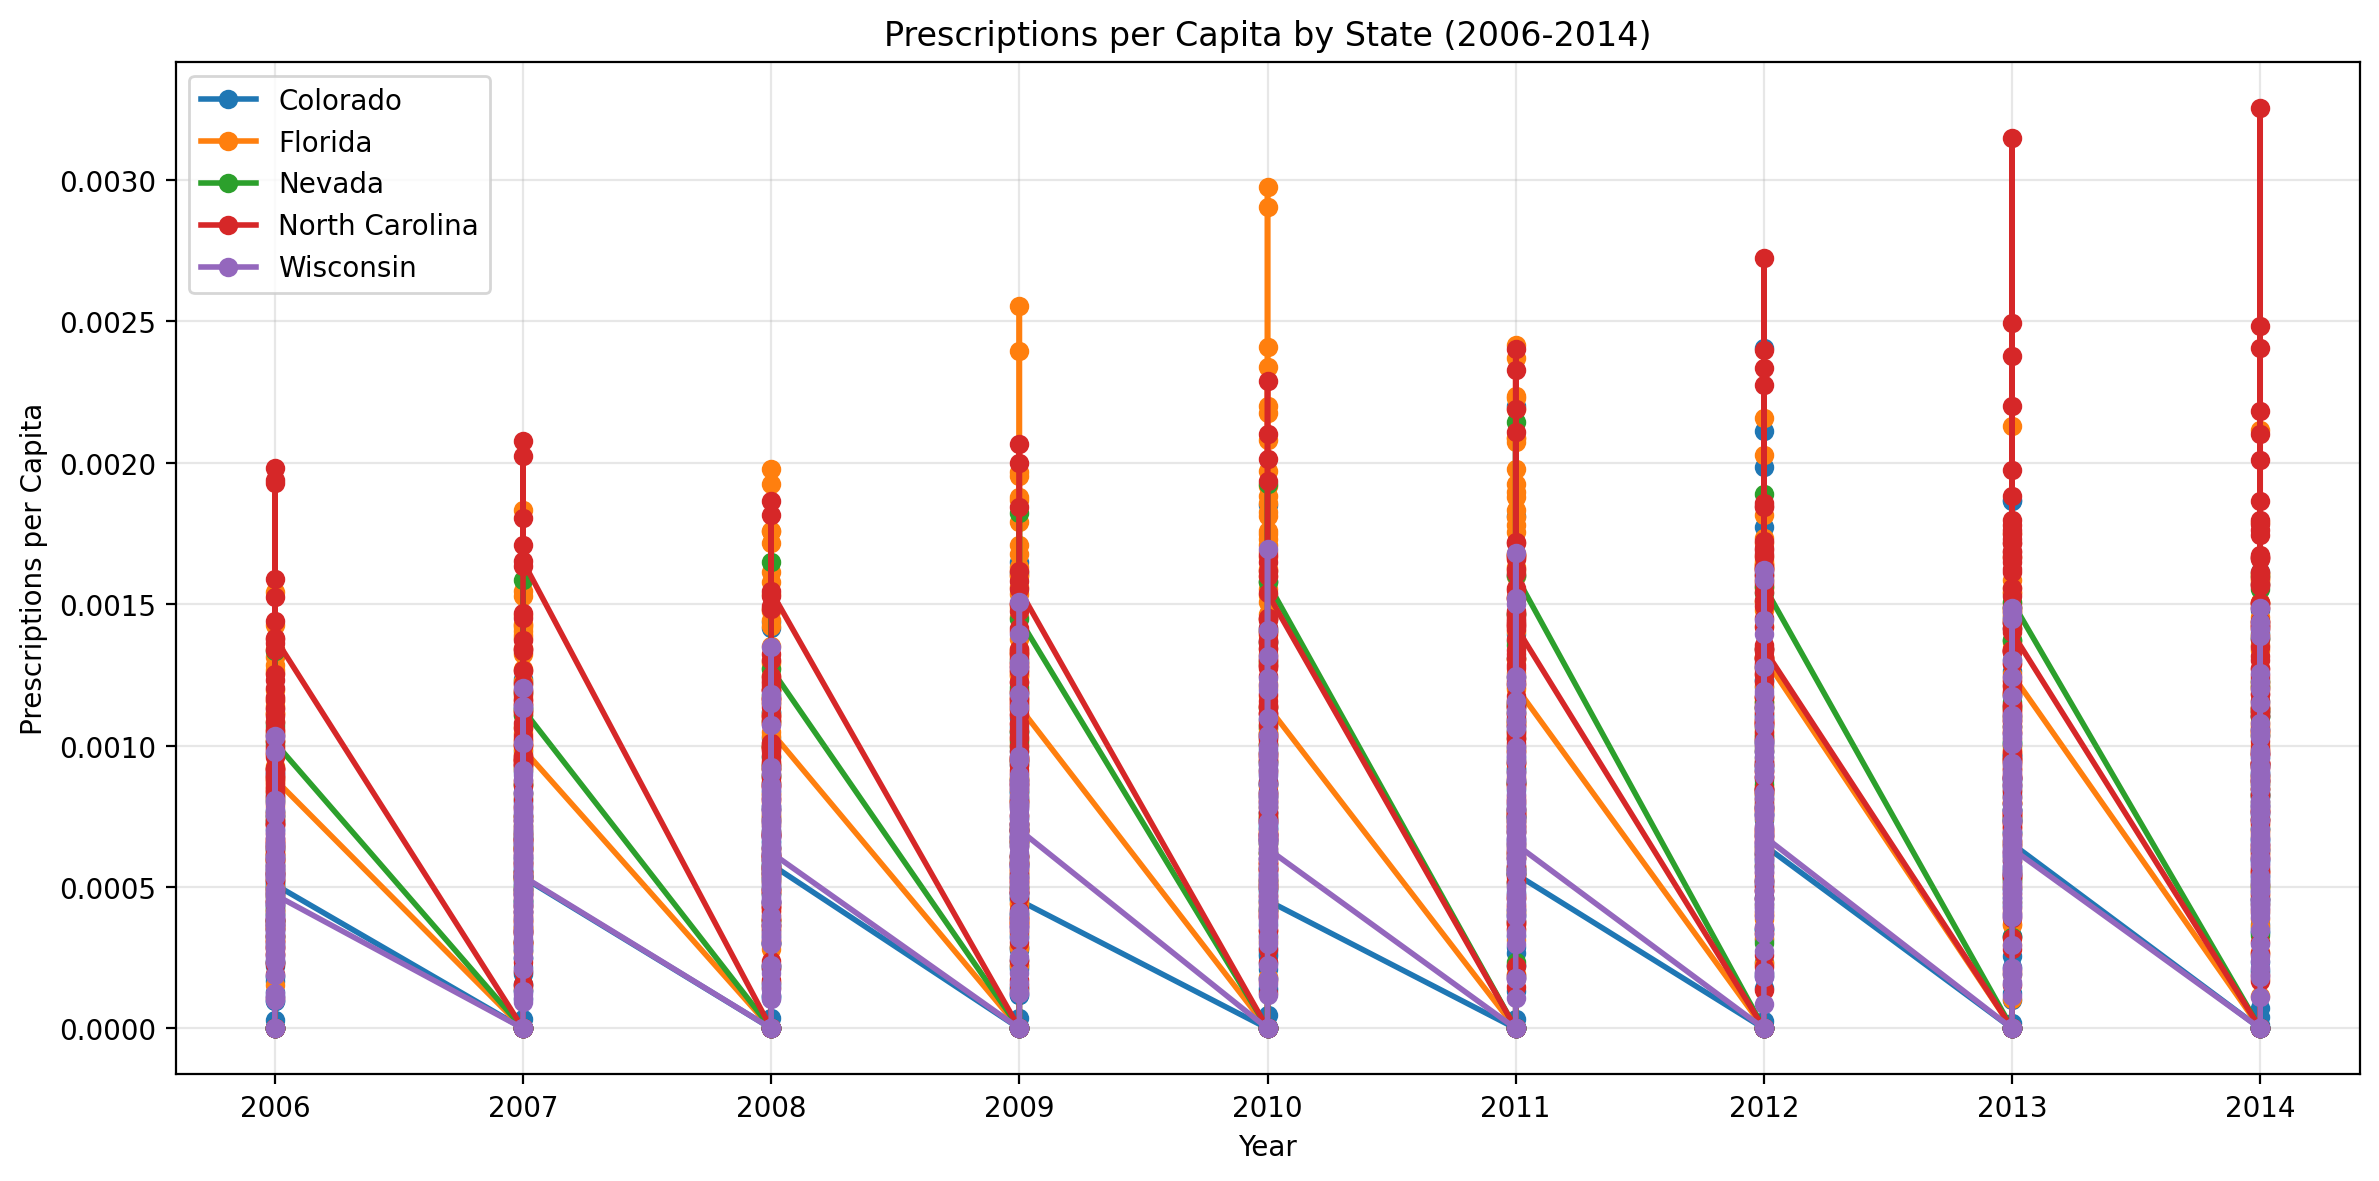

In [257]:
import matplotlib.pyplot as plt
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats("retina")


# Plot each state
fig, ax = plt.subplots(figsize=(12, 6))

for state in final_prescription_per_capita_long["STNAME"].unique():
    state_data = final_prescription_per_capita_long[
        final_prescription_per_capita_long["STNAME"] == state
    ]
    ax.plot(
        state_data["Year"],
        state_data["Prescriptions_per_Capita"],
        marker="o",
        linewidth=2,
        label=state,
    )

ax.set_xlabel("Year")
ax.set_ylabel("Prescriptions per Capita")
ax.set_title("Prescriptions per Capita by State (2006-2014)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [259]:
florida_data_long = final_prescription_per_capita_long[
    final_prescription_per_capita_long["STNAME"] == "Florida"
]
florida_data_long.head()

,STNAME,CTYNAME,FIPS,Year,Prescriptions_per_Capita
65,Florida,Florida,12000,2006,0.000000
66,Florida,Alachua County,12001,2006,0.001286
67,Florida,Baker County,12003,2006,0.001086
68,Florida,Bay County,12005,2006,0.000812
69,Florida,Bradford County,12007,2006,0.001018


> Goal: Try to make pre-post analysis graph for Florida. 
> Note that values look realy ugly due to the range per year. Consider removing points to only include line? 

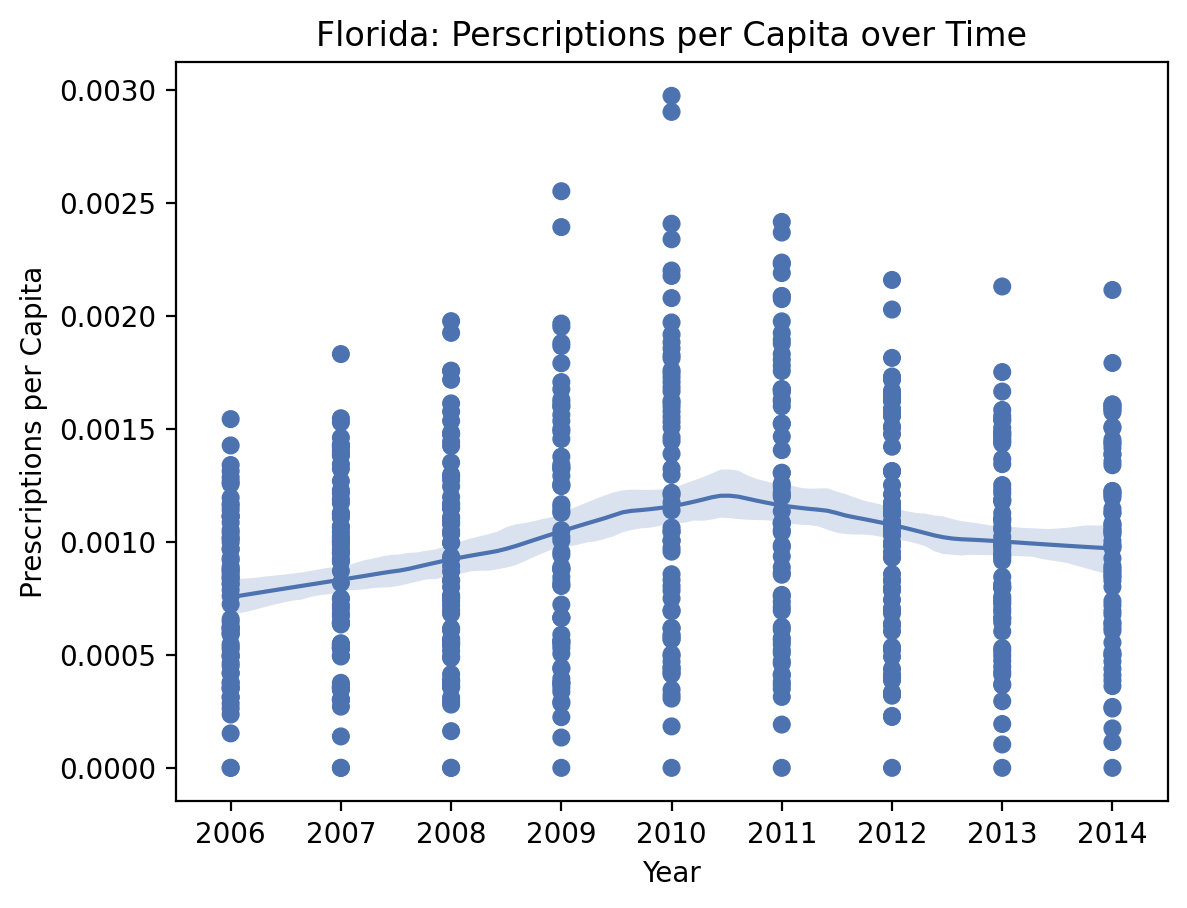

In [263]:
import seaborn.objects as so
import seaborn_objects_recipes as sor

florida_data_long = final_prescription_per_capita_long[
    final_prescription_per_capita_long["STNAME"] == "Florida"
]

fig, ax = plt.subplots()

# Make a seaborn objects plot
plot = (
    so.Plot(florida_data_long, x="Year", y="Prescriptions_per_Capita")
    .add(so.Dot())
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.4, gridsize=100, num_bootstrap=200, alpha=0.95),
    )
    .add(so.Band(), lowess)
    .label(
        x="Year",
        y="Prescriptions per Capita",
        title="Lowess Plot with Confidence Intervals",
    )
)
plot

plot.on(ax).plot()
ax.set_facecolor("white")
ax.set_title("Florida: Perscriptions per Capita over Time")
fig.savefig("florida_pp1.png")

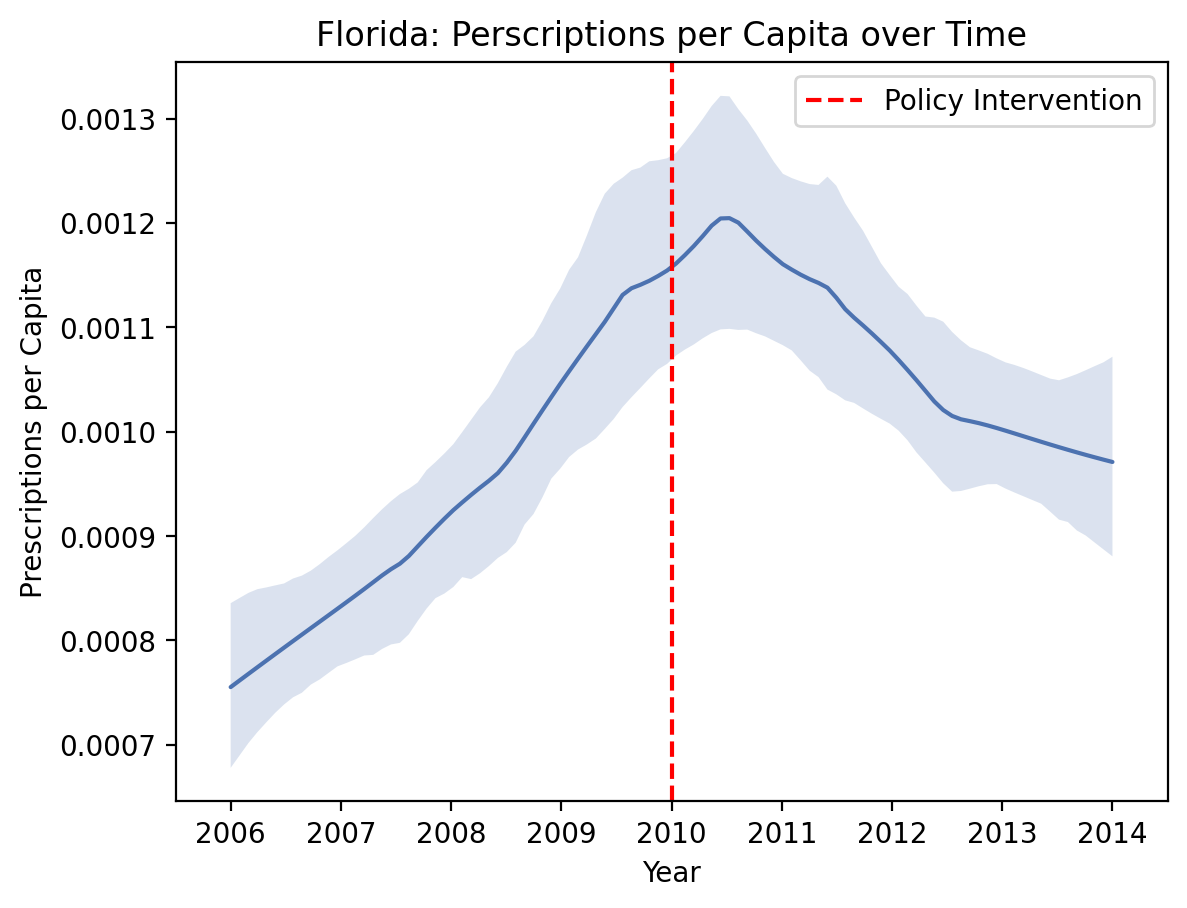

In [275]:
# Edited Version removing points.

import seaborn.objects as so
import seaborn_objects_recipes as sor

florida_data_long = final_prescription_per_capita_long[
    final_prescription_per_capita_long["STNAME"] == "Florida"
]

fig, ax = plt.subplots()

# Make a seaborn objects plot
plot = (
    so.Plot(florida_data_long, x="Year", y="Prescriptions_per_Capita")
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.4, gridsize=100, num_bootstrap=200, alpha=0.95),
    )
    .add(so.Band(), lowess)
    .label(
        x="Year",
        y="Prescriptions per Capita",
        title="Lowess Plot with Confidence Intervals",
    )
)
plot
plot.on(ax).plot()
ax.axvline(x=4, color="red", linestyle="--", label="Policy Intervention")
ax.set_facecolor("white")
ax.set_title("Florida: Perscriptions per Capita over Time")
fig.savefig("florida_pp2.png")
ax.legend()

In [ ]:
# Difference of Differences Graph + Calculations
fig, ax = plt.subplots()

# Make a seaborn objects plot
plot = (
    so.Plot(final_prescription_per_capita_long, x="Year", y="Prescriptions_per_Capita")
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.4, gridsize=100, num_bootstrap=200, alpha=0.95),
    )
    .add(so.Band(), lowess)
    .label(
        x="Year",
        y="Prescriptions per Capita",
        title="Lowess Plot with Confidence Intervals",
    )
)
plot
plot.on(ax).plot()
ax.axvline(x=4, color="red", linestyle="--", label="Policy Intervention")
ax.set_facecolor("white")
ax.set_title("Florida: Perscriptions per Capita over Time")
fig.savefig("florida_pp2.png")
ax.legend()

In [276]:
final_prescription_per_capita_long.head(n=10)

,STNAME,CTYNAME,FIPS,Year,Prescriptions_per_Capita
0,Colorado,Colorado,08000,2006,0.000000
1,Colorado,Adams County,08001,2006,0.000505
2,Colorado,Alamosa County,08003,2006,0.001039
3,Colorado,Arapahoe County,08005,2006,0.000511
4,Colorado,Archuleta County,08007,2006,0.000235
5,Colorado,Baca County,08009,2006,0.000899
6,Colorado,Bent County,08011,2006,0.000186
7,Colorado,Boulder County,08013,2006,0.000607
8,Colorado,Broomfield County,08014,2006,0.000550
9,Colorado,Chaffee County,08015,2006,0.000731


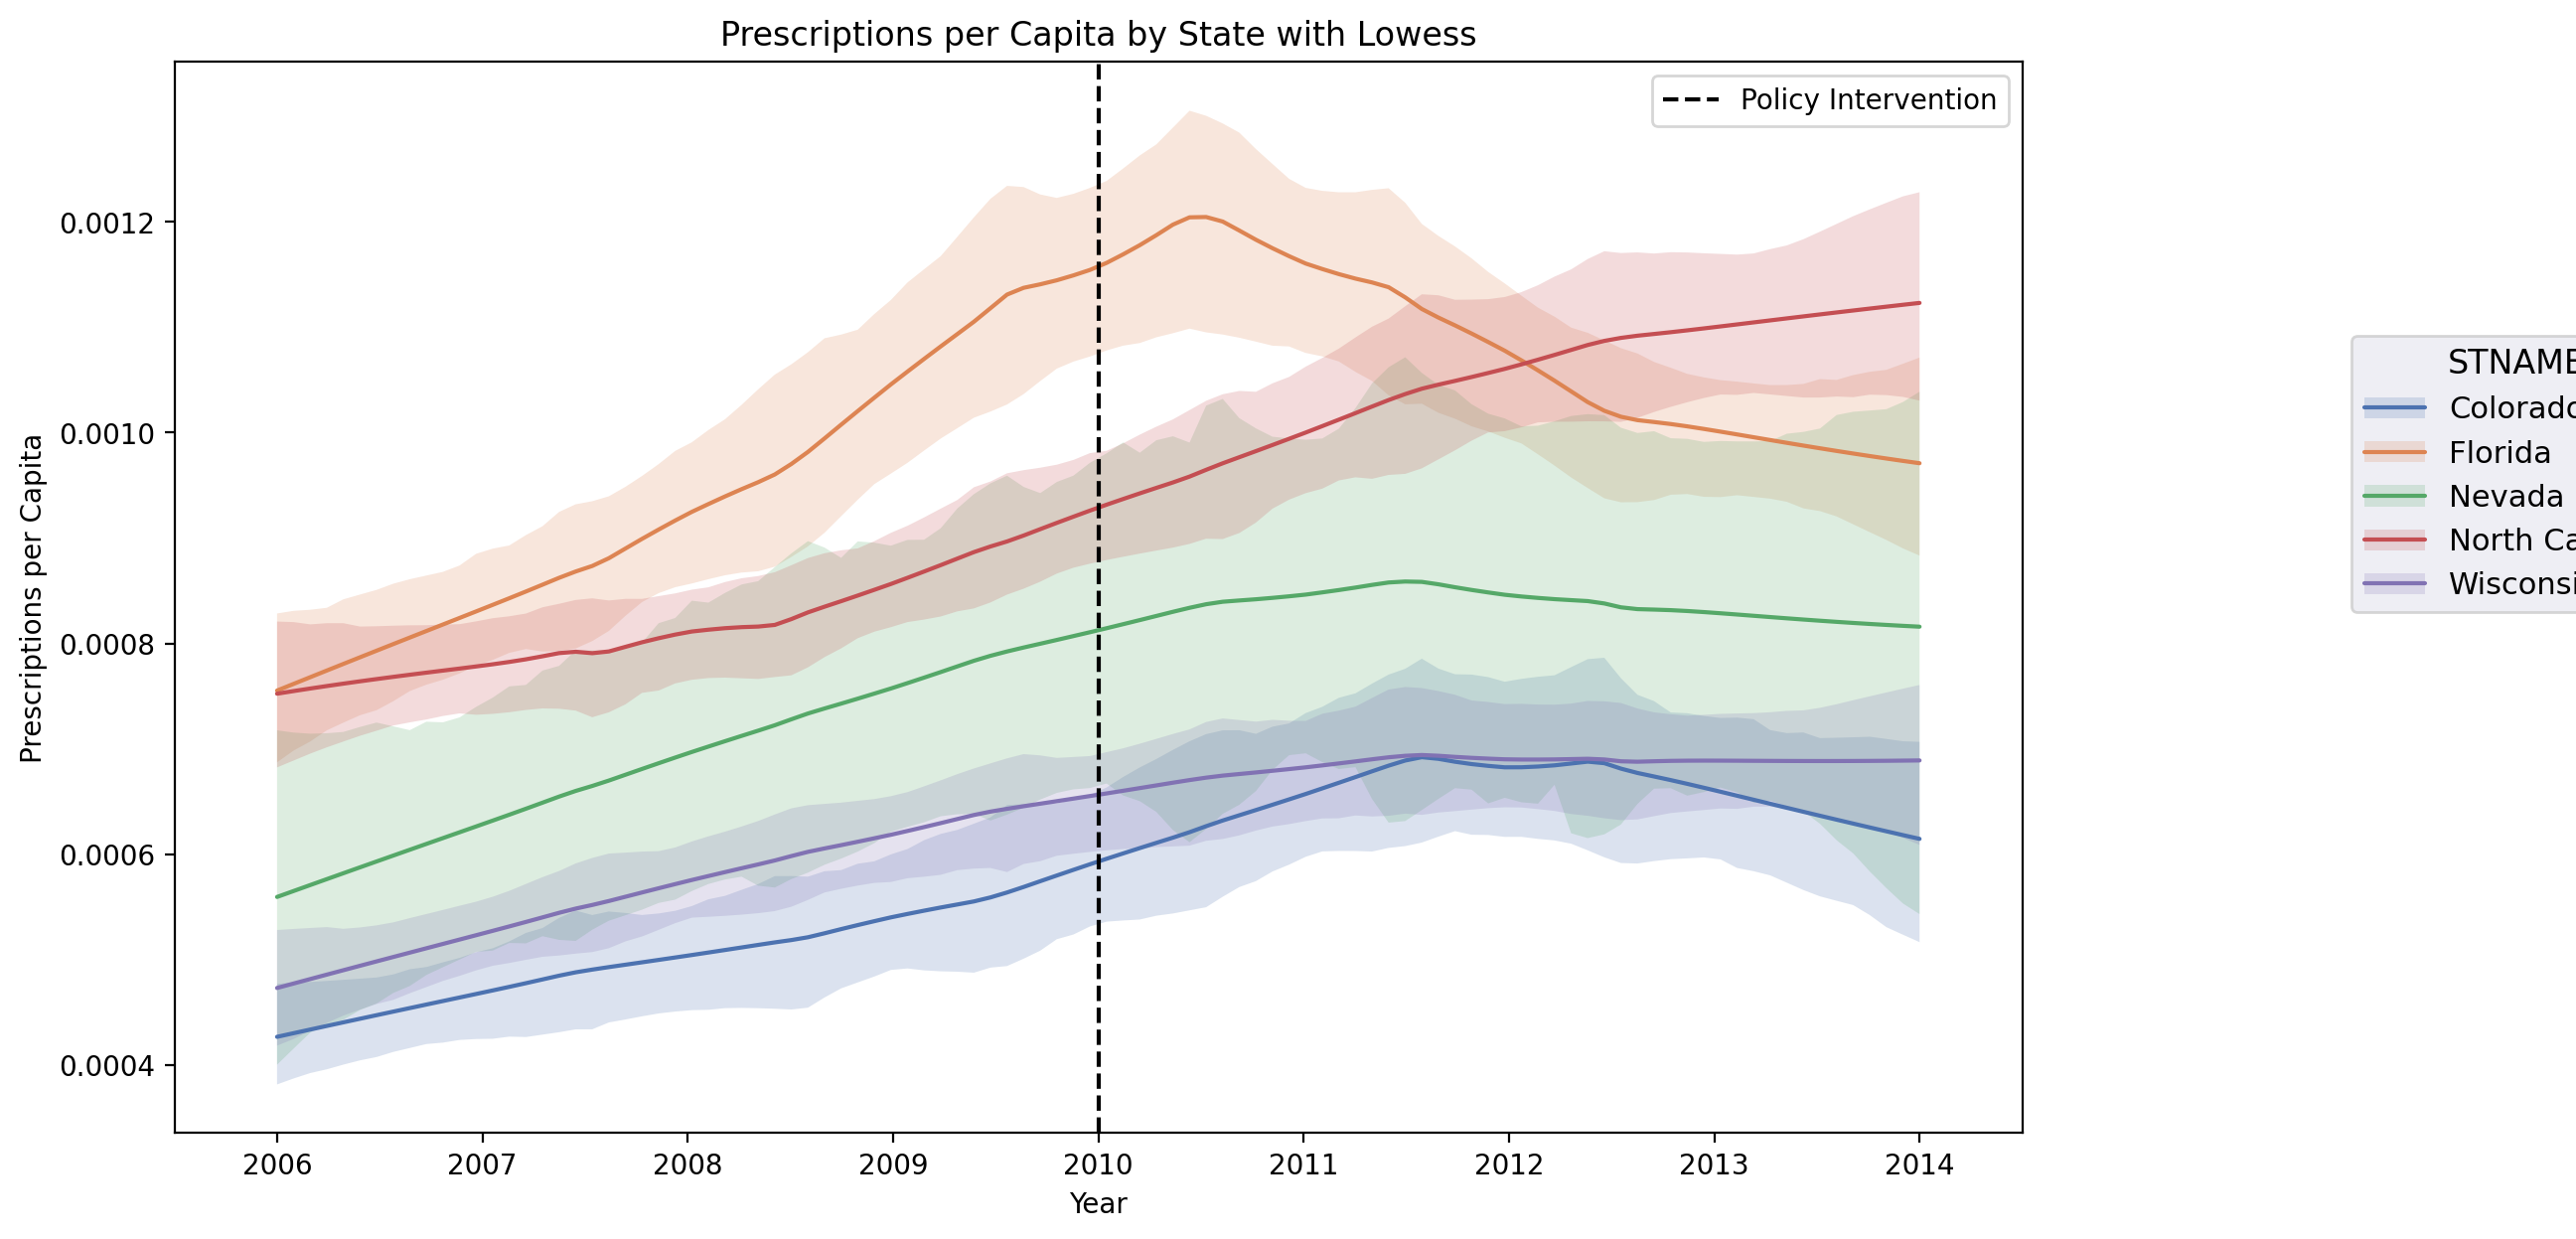

In [ ]:
import seaborn.objects as so
import seaborn_objects_recipes as sor
import matplotlib.pyplot as plt

lowess = sor.Lowess(frac=0.4, gridsize=100, num_bootstrap=200, alpha=0.95)

fig, ax = plt.subplots(figsize=(12, 7))

(
    so.Plot(
        final_prescription_per_capita_long,
        x="Year",
        y="Prescriptions_per_Capita",
        color="STNAME",
    )
    .add(so.Line(), lowess)  # smoothed lines
    .add(so.Band(), lowess)  # CI bands
    .on(ax)
    .plot()
)

# Policy line
ax.axvline(4, color="black", linestyle="--", label="Policy Intervention")

ax.set_title("Prescriptions per Capita by State with Lowess")
ax.set_xlabel("Year")
ax.set_ylabel("Prescriptions per Capita")

ax.legend()
fig.savefig("prescriptionsDID.png", bbox_inches="tight")